# Bias-variance in the Linear model

## Initialize

In [1]:
# import required libraries
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf #type: ignore
import torch #type: ignore
#
from IPython.display import display, Math
# Import typyng library for type hinting
from typing import Callable, Union, List, Any, Tuple
#
# Initialize pretty printing
sp.init_printing()

## True Model Definition

In [2]:
def series_expansion(f: sp.Expr, 
                     x: sp.Symbol, 
                     a: Union[int, float], 
                     n: int
                    ) -> sp.Expr:
    """
    Expands the given function f around point a to the n-th order.
    
    Args:
        f: A SymPy function to be expanded.
        x: The symbolic variable used in function f.
        a: The point around which the series is expanded.
        n: The order up to which the series is expanded.
        
    Returns:
        The series expansion of f as a SymPy expression.
    """
    return f.series(x, a, n+1).removeO()

def evaluate_expansion(expansion_func: Callable[[np.ndarray], np.ndarray], 
                       x_values: np.ndarray
                      ) -> np.ndarray:
    """
    Evaluates a given series expansion function for an array of x values.
    
    Args:
        expansion_func: A lambda function that takes x_values and evaluates the series expansion.
        x_values: A numpy array of x values at which to evaluate the expansion.
        
    Returns:
        A numpy array containing the evaluated series expansion at each x value.
    """
    try:
        result: np.ndarray = expansion_func(x_values)  # Variable annotation for Python 3.9+
        if np.isscalar(result):
            result = np.full(shape=x_values.shape, fill_value=result)  # Reusing annotation
    except TypeError:
        # Handles cases where the expansion function does not naturally vectorize
        result = np.vectorize(expansion_func)(x_values)  # Reusing annotation
    return result

# Main execution
if __name__ == "__main__": # not necessary when running in a Jupyter notebook
    i: int
    # Define the symbolic variable
    x: sp.Symbol = sp.symbols('x')

    # Define the function
    func: sp.Expr = sp.sympify(3) + sp.sin(x) - sp.cos(x)

    print("Function:", func)
    for i in range(10):
        # Generate and print series expansion up to x^i
        expn: sp.Expr = series_expansion(func, x, 0, i)
        print(f"Series Expansion at x^{i}:", expn)

        # Example: Convert series expansion to a lambda function for evaluation
        # (Illustration purposes; adjust x_vals as needed)
        x_vals: np.ndarray = np.linspace(-4, 4, 400)
        lambda_expn: Callable[[np.ndarray], np.ndarray] = sp.lambdify(x, expn, 'numpy')
        evaluated_vals: np.ndarray = evaluate_expansion(lambda_expn, x_vals)
        
        # The `evaluate_expansion` function's usage depends on further processing or plotting of `evaluated_vals`


Function: sin(x) - cos(x) + 3
Series Expansion at x^0: 2
Series Expansion at x^1: x + 2
Series Expansion at x^2: x**2/2 + x + 2
Series Expansion at x^3: -x**3/6 + x**2/2 + x + 2
Series Expansion at x^4: -x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^5: x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^6: x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^7: -x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^8: -x**8/40320 - x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^9: x**9/362880 - x**8/40320 - x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2


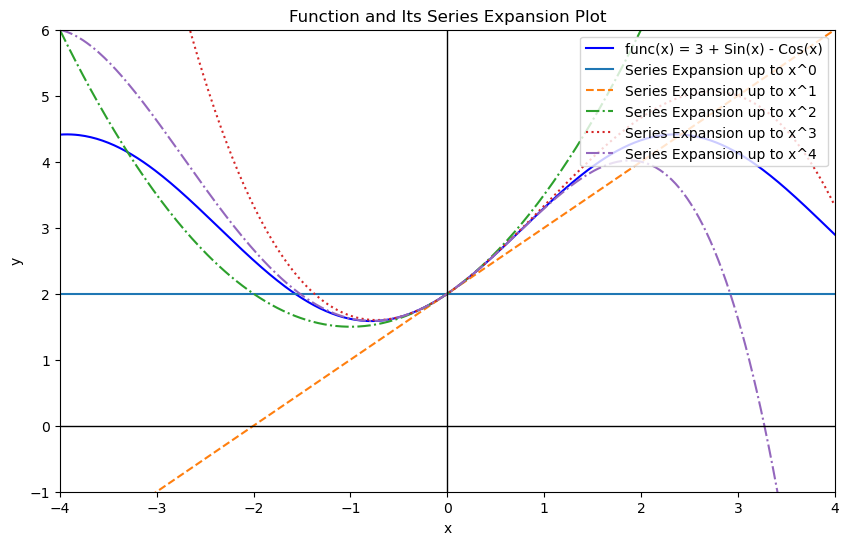

In [3]:
# Lambda function to convert SymPy expressions to NumPy functions
def sympy_to_numpy_function(sympy_func: sp.Expr, 
                            symbol: sp.Symbol
                           ) -> Callable[[np.ndarray], np.ndarray]:
    """
    Converts a SymPy function of a single variable to a NumPy-compatible function.
    
    Args:
        sympy_func: A SymPy expression representing the function.
        symbol: The SymPy symbol used in sympy_func.
    
    Returns:
        A lambda function that evaluates sympy_func over NumPy arrays.
    """
    return sp.lambdify(symbol, sympy_func, modules=['numpy'])

# Function to evaluate series expansions
def evaluate_expansion(expansion_func: Callable[[np.ndarray], np.ndarray], 
                       x_values: np.ndarray
                      ) -> np.ndarray:
    """
    Evaluates a given series expansion function for an array of x values.
    
    Args:
        expansion_func: A lambda function that takes x_values and evaluates the series expansion.
        x_values: A numpy array of x values at which to evaluate the expansion.
        
    Returns:
        A numpy array containing the evaluated series expansion at each x value.
    """
    # Evaluate the expansion for the provided x values
    result: np.ndarray = expansion_func(x_values)
    
    # Check if the result is a scalar and, if so, create an array filled with this value
    if np.isscalar(result):
        result = np.full_like(x_values, fill_value=result)
    
    return result

# Generate x values
x_values: np.ndarray = np.linspace(-4, 4, 400)

# Convert the main function to a numerical function and evaluate
func_lambdified: Callable[[np.ndarray], np.ndarray] = sympy_to_numpy_function(func, x)
y_values_func: np.ndarray = func_lambdified(x_values)

# Define line styles for different series expansions
line_styles: List[str] = ['-', '--', '-.', ':', 'dashdot']

# Plot the original function
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values_func, label='func(x) = 3 + Sin(x) - Cos(x)', color='blue', linestyle='-')

# Plot series expansions
n: int
style: str
for n, style in zip(range(5), line_styles):
    expansion_expr: sp.Expr = series_expansion(func, x, 0, n)
    expansion_lambdified: Callable[[np.ndarray], np.ndarray] = sympy_to_numpy_function(expansion_expr, x)
    y_values_expansion: np.ndarray = evaluate_expansion(expansion_lambdified, x_values)
    plt.plot(x_values, y_values_expansion, label=f'Series Expansion up to x^{n}', linestyle=style)

# Finalizing the plot
plt.title('Function and Its Series Expansion Plot')
plt.axhline(y=0, color='k', linestyle='-', linewidth=1)  # Horizontal line for x-axis
plt.axvline(x=0, color='k', linestyle='-', linewidth=1)  # Vertical line for y-axis
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.xlim(-4, 4)
plt.ylim(-1, 6)
plt.show()


## Numpy code

### Probabilistic model (polynomial data)

In [443]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix(degree: int, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array.
    """
    return np.array([[x**i for i in range(degree+1)] for x in x_values])

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def poly_solution(omega_solution: np.ndarray) -> Polynomial:
    """Converts omega coefficients to a numpy Polynomial object.
    
    Args:
        omega_solution: A numpy array of omega coefficients.
    
    Returns:
        A numpy Polynomial object representing the fitted polynomial.
    """
    return Polynomial(omega_solution)

In [444]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [445]:
def fit(data: np.ndarray,
        d: int,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of degree d to the given data and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix(d, dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        poly = poly_solution(omega)
        val = poly(x)
        result.append(val)
    return np.array(result)

In [446]:
fit(train_data, 3, x_values)

array([[3.25581018, 2.233492  , 2.44612719, 3.22223603, 3.89033881,
        3.7789558 , 2.21660731]])

In [447]:
fit(train_MC, 3, x_values)

array([[5.20256288, 2.5745848 , 1.77064255, ..., 2.87954765, 3.41473608,
        3.01864248],
       [6.31255258, 1.97038503, 1.1326947 , ..., 4.0091147 , 4.74240954,
        3.01855061],
       [4.68723732, 2.01569147, 1.34106384, ..., 2.84566773, 3.45645149,
        2.92725797],
       ...,
       [4.70063054, 2.63664735, 1.76452261, ..., 1.82304792, 1.8672977 ,
        1.33060537],
       [5.96801499, 1.91300172, 0.86169998, ..., 2.5086146 , 2.57602271,
        0.38552586],
       [3.86268523, 1.32345491, 0.88393333, ..., 2.60223425, 2.90916568,
        1.6140237 ]], shape=(1000, 7))

In [448]:
np.mean(fit(train_MC, 3, x_values), axis=0)

array([4.87192469, 2.17290124, 1.69106103, 2.4195304 , 3.35143573,
       3.47990335, 1.79805962])

In [449]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [450]:
Ef(3, x_values)

array([4.87192469, 2.17290124, 1.69106103, 2.4195304 , 3.35143573,
       3.47990335, 1.79805962])

In [451]:
Varf(3, x_values)

In [452]:
Bias2f(3, x_values)

In [453]:
Noise_variance(x_val)

In [454]:
MSE_MC(3)

In [455]:
result: list = []
for d in range(10):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


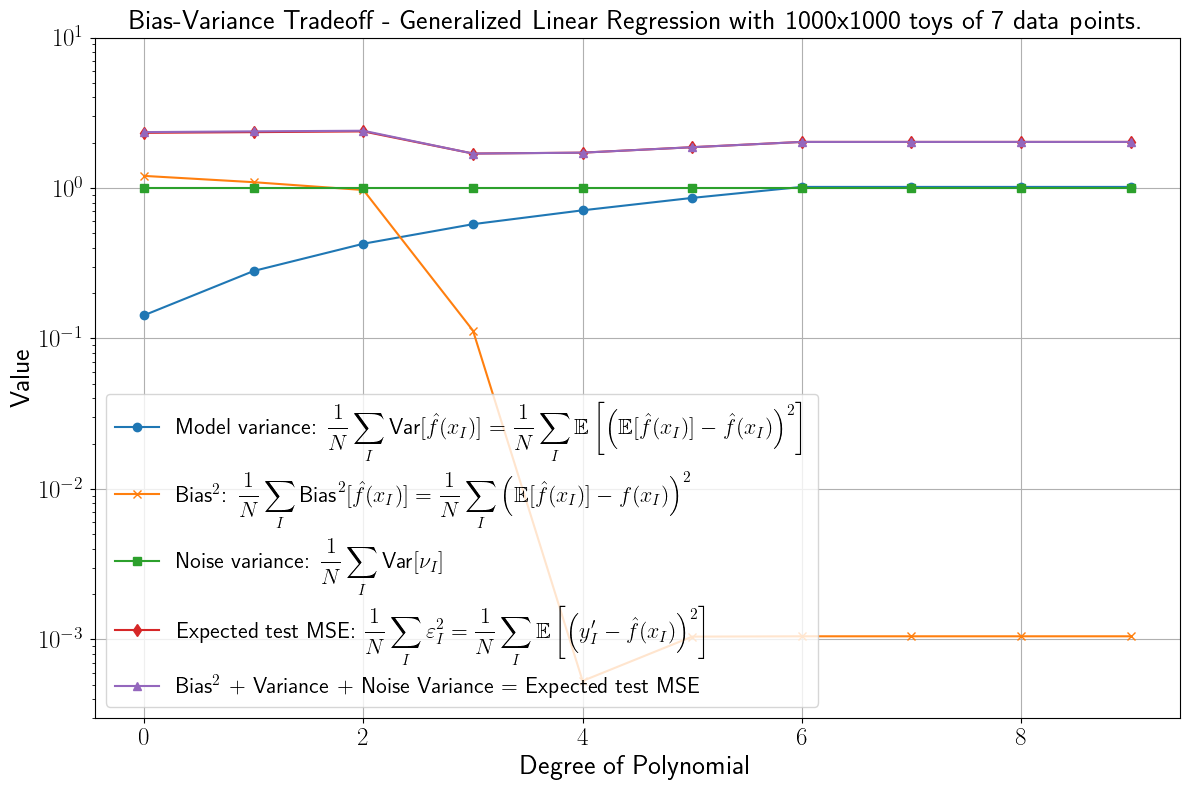

In [456]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-4, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_1.pdf')
plt.show()

### Probabilistic model (non-polynomial data)

In [457]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

In [458]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [459]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [460]:
Ef(3, x_values)

array([4.03332079, 2.13372056, 1.73015819, 2.27921056, 3.23745457,
       4.06146709, 4.20782501])

In [461]:
Varf(3, x_values)

In [462]:
Bias2f(3, x_values)

In [463]:
Noise_variance(x_val)

In [464]:
MSE_MC(3)

In [465]:
result: list = []
for d in range(10):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


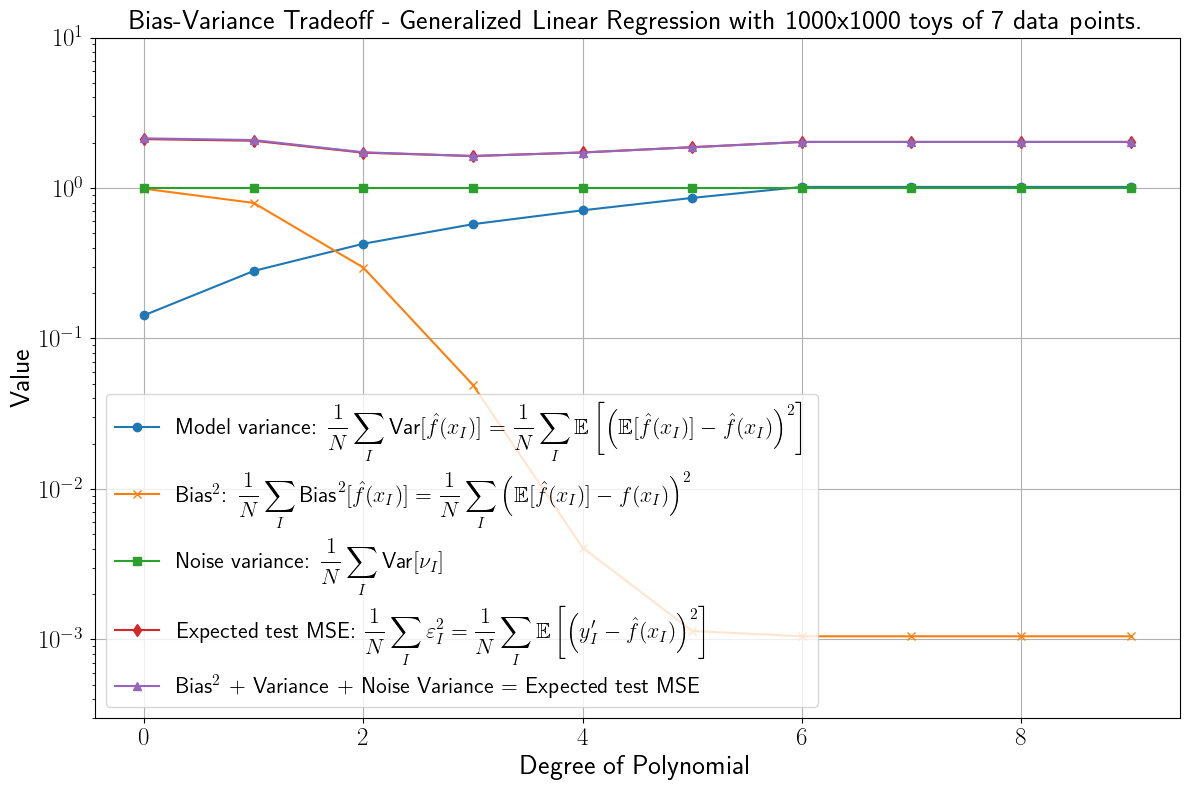

In [467]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-4, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_2.pdf')
plt.show()

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [469]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix_trig(x_values: np.ndarray) -> np.ndarray:
    """Generates a design matrix for trigonometric regression.
    
    Args:
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array with columns for 1, sin(x), and cos(x).
    """
    # The design matrix includes columns for the constant term, sin(x), and cos(x)
    return np.column_stack((np.ones_like(x_values), np.sin(x_values), np.cos(x_values)))

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the coefficients (omega) that best fit the data for a given design matrix.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def trig_solution(omega_solution: np.ndarray, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A numpy array of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A numpy array of x values for evaluation.
    
    Returns:
        A numpy array of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * np.sin(x_values) + omega_solution[2] * np.cos(x_values)


In [470]:
def fit(data: np.ndarray,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of trigonometric functions and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix_trig(dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        val = trig_solution(omega, x)
        result.append(val)
    return np.array(result)

In [471]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [472]:
def Ef(x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, x)
    return np.mean(fit_vals, axis=0)

def Varf(x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC() -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [473]:
Ef(x_values)

array([3.84835367, 2.5157108 , 1.62149407, 1.98784221, 3.27793643,
       4.30567006, 4.12614954])

In [474]:
Varf(x_values)

In [475]:
Bias2f(x_values)

In [476]:
Noise_variance(x_val)

In [477]:
MSE_MC()

In [478]:
Varf_val = Varf(x_values)
Bias2f_val = Bias2f(x_values)
Noise_variance_val = Noise_variance(x_values)
sum_val = Bias2f_val + Varf_val + Noise_variance_val
MSE_MC_val = MSE_MC()
print(Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val)

0.43146923314431573 0.00017038124360916292 1.006137500361673 1.437777114749598 1.4377881212881205


### Probabilistic model (polynomial data) - Large sample small variance

In [479]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix(degree: int, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array.
    """
    return np.array([[x**i for i in range(degree+1)] for x in x_values])

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def poly_solution(omega_solution: np.ndarray) -> Polynomial:
    """Converts omega coefficients to a numpy Polynomial object.
    
    Args:
        omega_solution: A numpy array of omega coefficients.
    
    Returns:
        A numpy Polynomial object representing the fitted polynomial.
    """
    return Polynomial(omega_solution)

In [480]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 0.1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 0.1, 1)
test_data = generate_data(x_values, 0.1, 1)
train_MC = generate_data(x_values, 0.1, 1000)
test_MC = generate_data(x_values, 0.1, 1000)

In [481]:
def fit(data: np.ndarray,
        d: int,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of degree d to the given data and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix(d, dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        poly = poly_solution(omega)
        val = poly(x)
        result.append(val)
    return np.array(result)

In [482]:
fit(train_data, 3, x_values)

array([[5.2927403 , 4.86631204, 4.47154085, 4.10744969, 3.77306151,
        3.4673993 , 3.189486  , 2.9383446 , 2.71299804, 2.51246931,
        2.33578136, 2.18195716, 2.05001967, 1.93899187, 1.84789671,
        1.77575716, 1.72159619, 1.68443677, 1.66330185, 1.6572144 ,
        1.66519739, 1.68627379, 1.71946656, 1.76379866, 1.81829306,
        1.88197273, 1.95386063, 2.03297973, 2.11835299, 2.20900338,
        2.30395386, 2.4022274 , 2.50284696, 2.60483552, 2.70721603,
        2.80901146, 2.90924478, 3.00693895, 3.10111693, 3.1908017 ,
        3.27501622, 3.35278345, 3.42312636, 3.48506792, 3.53763108,
        3.57983882, 3.6107141 , 3.62927989, 3.63455915, 3.62557485,
        3.60134995, 3.56090742, 3.50327022, 3.42746132, 3.33250369,
        3.21742028, 3.08123407, 2.92296803, 2.74164511, 2.53628828,
        2.30592051]])

In [483]:
fit(train_MC, 3, x_values)

array([[5.24337674, 4.81840212, 4.42520953, ..., 2.75302929, 2.54404532,
        2.30974277],
       [5.32519286, 4.89655519, 4.49978164, ..., 2.75075518, 2.5424771 ,
        2.30894878],
       [5.3572204 , 4.92682796, 4.52823328, ..., 2.85230475, 2.65347616,
        2.42985915],
       ...,
       [5.35991081, 4.9211883 , 4.51504292, ..., 2.81591843, 2.60873621,
        2.37595801],
       [5.30062621, 4.8681532 , 4.46794541, ..., 2.79133965, 2.58237837,
        2.34786227],
       [5.26797075, 4.84086064, 4.44546835, ..., 2.80146134, 2.60021594,
        2.37406488]], shape=(1000, 61))

In [484]:
np.mean(fit(train_MC, 3, x_values), axis=0)

array([5.3229215 , 4.88831139, 4.48608413, 4.11523906, 3.77477549,
       3.46369278, 3.18099025, 2.92566724, 2.69672309, 2.49315713,
       2.31396869, 2.15815711, 2.02472173, 1.91266188, 1.8209769 ,
       1.74866612, 1.69472887, 1.65816449, 1.63797232, 1.63315169,
       1.64270194, 1.66562239, 1.7009124 , 1.74757128, 1.80459838,
       1.87099304, 1.94575458, 2.02788234, 2.11637565, 2.21023386,
       2.3084563 , 2.4100423 , 2.51399119, 2.61930232, 2.72497501,
       2.83000861, 2.93340244, 3.03415585, 3.13126816, 3.22373871,
       3.31056685, 3.39075189, 3.46329318, 3.52719006, 3.58144185,
       3.6250479 , 3.65700753, 3.67632009, 3.6819849 , 3.67300131,
       3.64836864, 3.60708624, 3.54815344, 3.47056957, 3.37333397,
       3.25544597, 3.11590491, 2.95371012, 2.76786094, 2.55735671,
       2.32119675])

In [485]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [486]:
Ef(3, x_values)

array([5.3229215 , 4.88831139, 4.48608413, 4.11523906, 3.77477549,
       3.46369278, 3.18099025, 2.92566724, 2.69672309, 2.49315713,
       2.31396869, 2.15815711, 2.02472173, 1.91266188, 1.8209769 ,
       1.74866612, 1.69472887, 1.65816449, 1.63797232, 1.63315169,
       1.64270194, 1.66562239, 1.7009124 , 1.74757128, 1.80459838,
       1.87099304, 1.94575458, 2.02788234, 2.11637565, 2.21023386,
       2.3084563 , 2.4100423 , 2.51399119, 2.61930232, 2.72497501,
       2.83000861, 2.93340244, 3.03415585, 3.13126816, 3.22373871,
       3.31056685, 3.39075189, 3.46329318, 3.52719006, 3.58144185,
       3.6250479 , 3.65700753, 3.67632009, 3.6819849 , 3.67300131,
       3.64836864, 3.60708624, 3.54815344, 3.47056957, 3.37333397,
       3.25544597, 3.11590491, 2.95371012, 2.76786094, 2.55735671,
       2.32119675])

In [487]:
Varf(3, x_values)

In [488]:
Bias2f(3, x_values)

In [489]:
Noise_variance(x_val)

In [490]:
MSE_MC(3)

In [491]:
result: list = []
for d in range(20):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


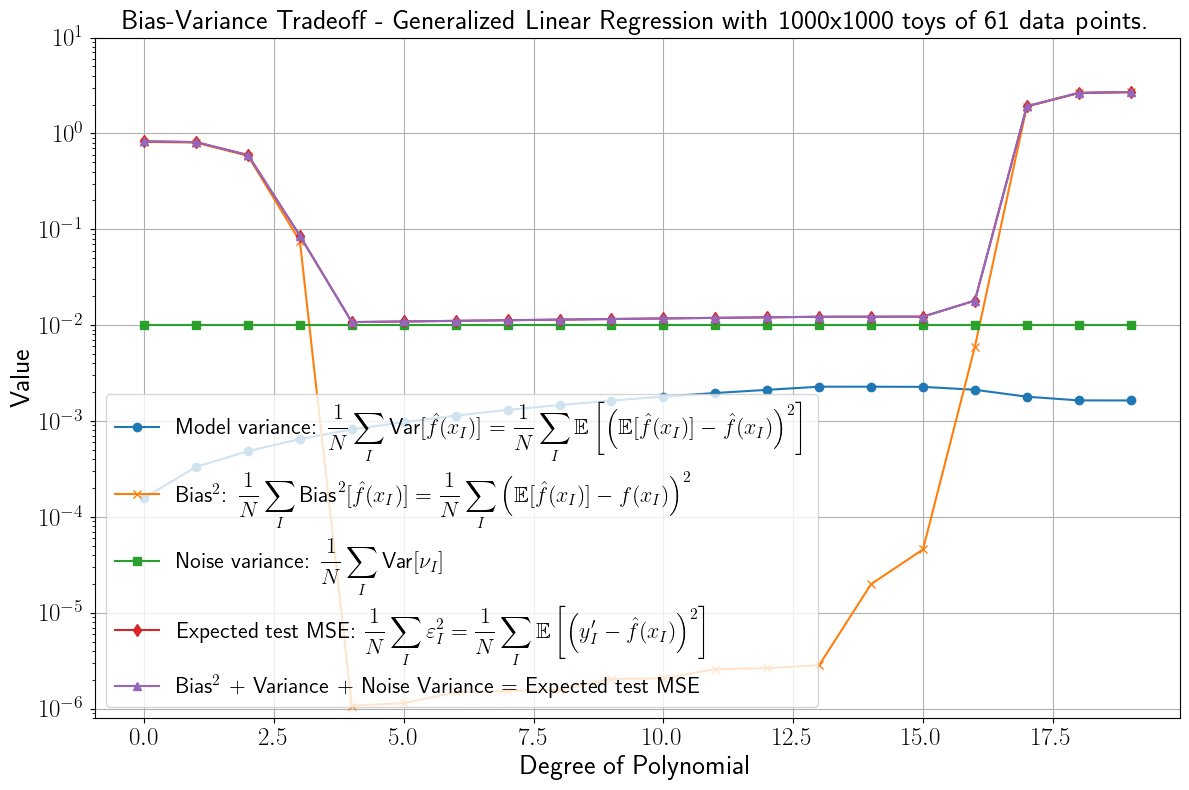

In [493]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(8e-7, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_3.pdf')
plt.show()

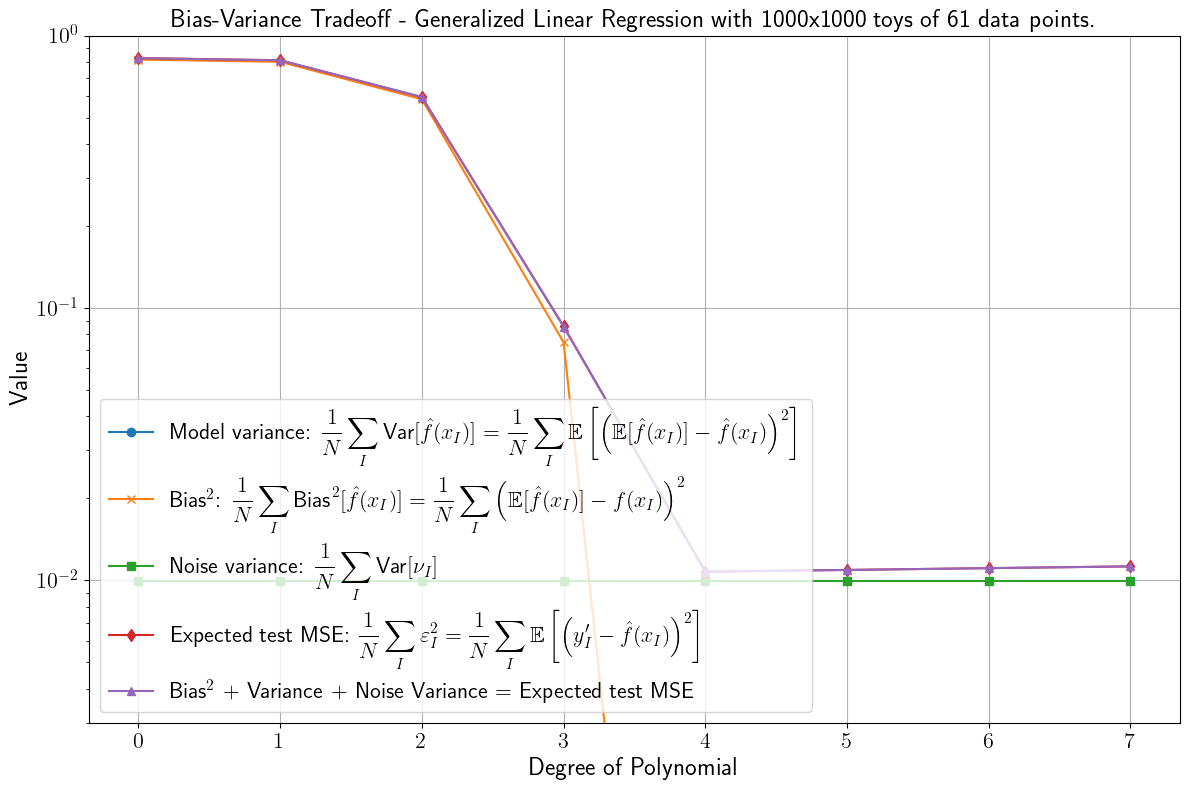

In [494]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result[:8])
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Degree of Polynomial', fontsize = 18)
plt.ylabel('Value', fontsize = 18)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 18)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-3, 1)
plt.tight_layout()
plt.show()

### Probabilistic model (non-polynomial data) - Large sample small variance

In [495]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

In [496]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 0.1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 0.1, 1)
test_data = generate_data(x_values, 0.1, 1)
train_MC = generate_data(x_values, 0.1, 1000)
test_MC = generate_data(x_values, 0.1, 1000)

In [497]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [498]:
Ef(3, x_values)

array([4.40443535, 4.09527674, 3.80784124, 3.5415472 , 3.29581296,
       3.07005689, 2.86369732, 2.67615261, 2.50684112, 2.35518118,
       2.22059116, 2.1024894 , 2.00029425, 1.91342407, 1.8412972 ,
       1.78333199, 1.7389468 , 1.70755998, 1.68858986, 1.68145482,
       1.68557319, 1.70036333, 1.72524359, 1.75963232, 1.80294786,
       1.85460857, 1.91403281, 1.98063891, 2.05384524, 2.13307013,
       2.21773195, 2.30724904, 2.40103975, 2.49852244, 2.59911544,
       2.70223713, 2.80730584, 2.91373992, 3.02095773, 3.12837761,
       3.23541793, 3.34149702, 3.44603323, 3.54844493, 3.64815045,
       3.74456816, 3.83711639, 3.9252135 , 4.00827785, 4.08572777,
       4.15698163, 4.22145777, 4.27857454, 4.3277503 , 4.36840338,
       4.39995216, 4.42181497, 4.43341016, 4.43415609, 4.4234711 ,
       4.40077356])

In [499]:
Varf(3, x_values)

In [500]:
Bias2f(3, x_values)

In [501]:
Noise_variance(x_val)

In [502]:
MSE_MC(3)

In [503]:
result: list = []
for d in range(20):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


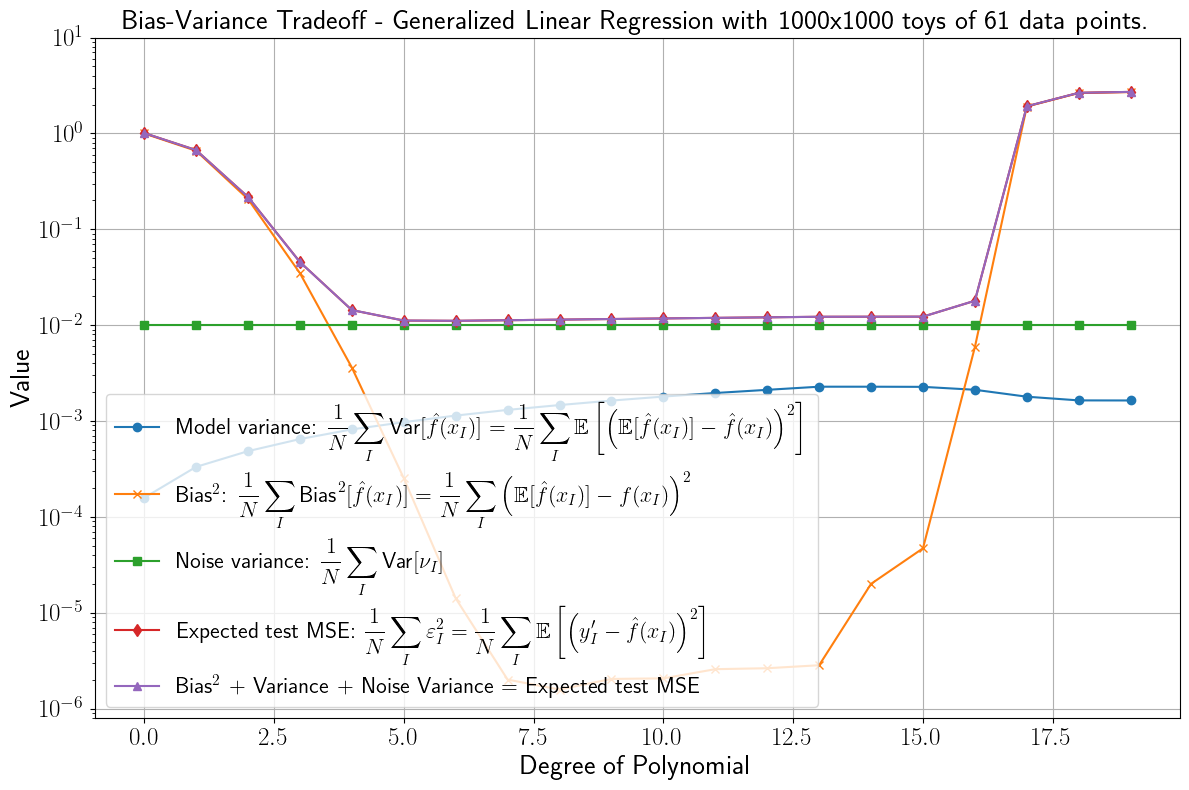

In [504]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(8e-7, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_4.pdf')
plt.show()

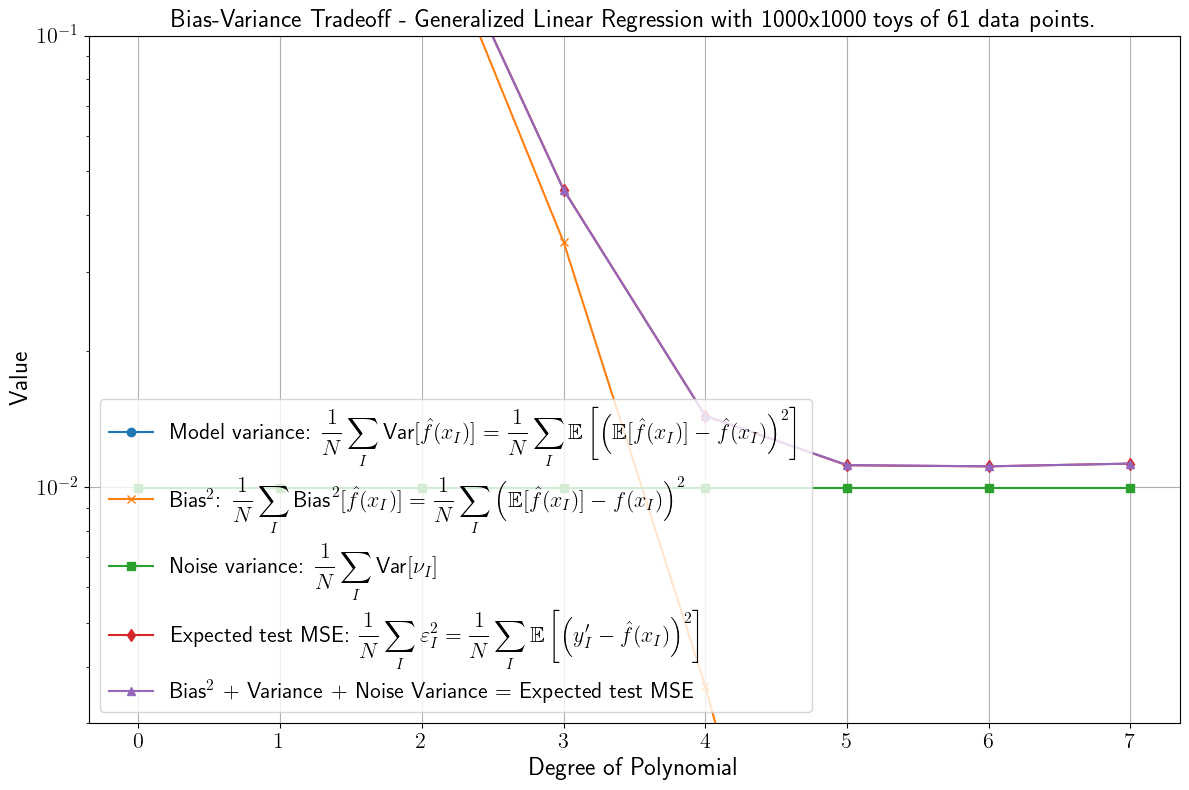

In [417]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result[:8])
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Degree of Polynomial', fontsize = 18)
plt.ylabel('Value', fontsize = 18)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 18)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-3, 0.1)
plt.tight_layout()
plt.show()

## TensorFlow2 code

## PyTorch code